# Step 8: Scale the Customer Churn Prototype

## Objective

This notebook prepares the customer churn prototype for substantially larger datasets.

It will:

- Confirm that the current prototype works with the complete 10,000-row dataset.
- Measure the runtime and memory characteristics of the existing Random Forest approach.
- Implement a bounded-memory training workflow using batches and `partial_fit`.
- Stress-test the workflow on a much larger streamed dataset without loading all rows into memory.
- Explain the trade-offs among scikit-learn, incremental learning, and distributed tools such as SparkML.

The original dataset remains the source of truth for model evaluation. The larger streamed dataset is used only to test scalability.


## Scaling Design

The existing Random Forest remains the preferred model for the current dataset because it achieved the strongest validation F1 score. However, Random Forest does not support incremental training and its memory use grows with both the number of observations and trees.

For scaling, this notebook adds an incremental alternative using:

- `StandardScaler.partial_fit`
- `SGDClassifier.partial_fit`
- Fixed-size batches
- Bootstrap sampling from the training set to generate a reproducible stress-test stream

Only one batch is held in memory at a time, so the workflow can process a dataset larger than available RAM.


In [1]:
import json
import time
import tracemalloc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Load the Complete Dataset

The path logic below allows the notebook to run from either the repository root or the `notebooks/` folder.


In [2]:
possible_paths = [
    Path("data/customer_churn_cleaned.csv"),
    Path("../data/customer_churn_cleaned.csv"),
    Path("Data/customer_churn_cleaned.csv"),
    Path("../Data/customer_churn_cleaned.csv"),
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not locate customer_churn_cleaned.csv in the project data folder."
    )

print(f"Loading dataset from: {data_path.resolve()}")

df = pd.read_csv(data_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Loading dataset from: /Users/jeffreyjolly/Desktop/ML:AI Capstone/data/customer_churn_cleaned.csv
Rows: 10,000
Columns: 9


,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,844,18,2,160980.03,145936.28,0,0,0,1
1,656,18,10,151762.74,127014.32,0,0,0,1
2,570,18,4,82767.42,71811.90,0,0,0,0
3,716,18,3,128743.80,197322.13,0,1,0,0
4,727,18,4,133550.67,46941.41,0,0,0,1


## Full-Dataset Validation

The prototype should first demonstrate that it can process the complete collected dataset before testing larger volumes.


In [3]:
print("Missing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

target_summary = (
    df["Exited"]
    .value_counts()
    .rename_axis("Exited")
    .to_frame("Count")
)
target_summary["Percent"] = 100 * target_summary["Count"] / len(df)
target_summary


Missing values:


CreditScore          0
Age                  0
Tenure               0
Balance              0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64


Duplicate rows: 0


,Count,Percent
Exited,,
0,7963,79.63
1,2037,20.37


In [4]:
X = df.drop(columns="Exited")
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")


Training rows: 8,000
Test rows: 2,000


## Baseline: Complete-Data Random Forest

The current model is retrained on the full training split. Runtime and peak Python memory allocation are recorded as a baseline.

`tracemalloc` does not capture every allocation made by compiled libraries, so the memory value is an engineering estimate rather than an exact system-level measurement.


In [5]:
baseline_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1
)

tracemalloc.start()
start_time = time.perf_counter()

baseline_model.fit(X_train, y_train)

baseline_training_time = time.perf_counter() - start_time
_, baseline_peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Model": "Random Forest",
    "Training Rows Processed": len(X_train),
    "Training Time (sec)": baseline_training_time,
    "Peak Python Memory (MB)": baseline_peak_memory / (1024 ** 2),
    "Accuracy": accuracy_score(y_test, baseline_predictions),
    "Precision": precision_score(y_test, baseline_predictions),
    "Recall": recall_score(y_test, baseline_predictions),
    "F1": f1_score(y_test, baseline_predictions),
    "ROC-AUC": roc_auc_score(y_test, baseline_probabilities),
}

pd.DataFrame([baseline_metrics])


,Model,Training Rows Processed,Training Time (sec),Peak Python Memory (MB),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,8000,1.782846,1.28685,0.766,0.445242,0.609337,0.514523,0.783778


## Memory Projection at Larger Data Volumes

This estimate covers only the numeric feature matrix. A real pandas workflow also requires index, object, model, and temporary-array memory, so total memory would be higher.


In [6]:
bytes_per_row = X_train.memory_usage(index=False, deep=True).sum() / len(X_train)

projected_rows = [
    10_000,
    100_000,
    1_000_000,
    10_000_000,
    100_000_000,
    1_000_000_000
]

memory_projection = pd.DataFrame({
    "Rows": projected_rows,
    "Estimated Feature Matrix Memory (GB)": [
        rows * bytes_per_row / (1024 ** 3)
        for rows in projected_rows
    ]
})

memory_projection


,Rows,Estimated Feature Matrix Memory (GB)
0,10000,0.000596
1,100000,0.005960
2,1000000,0.059605
3,10000000,0.596046
4,100000000,5.960464
5,1000000000,59.604645


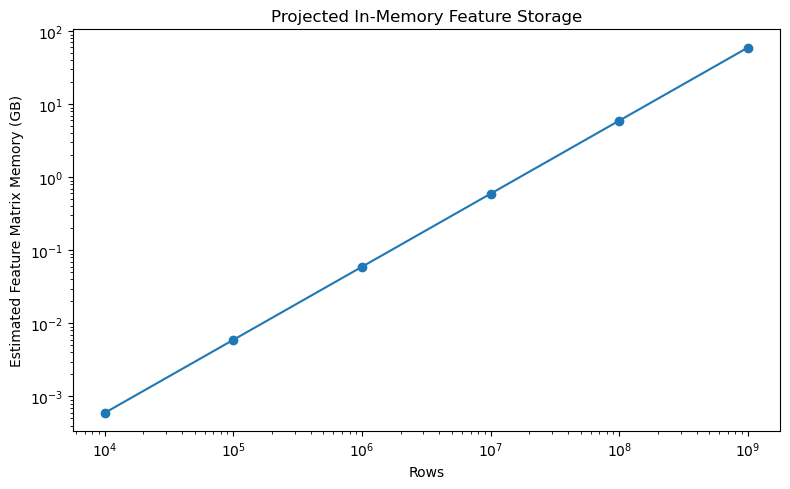

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(
    memory_projection["Rows"],
    memory_projection["Estimated Feature Matrix Memory (GB)"],
    marker="o"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rows")
plt.ylabel("Estimated Feature Matrix Memory (GB)")
plt.title("Projected In-Memory Feature Storage")
plt.tight_layout()
plt.show()


## Streaming Batch Generator

The generator creates one bootstrap batch at a time. It does not materialize the full expanded dataset.

Bootstrap rows are used only to test the engineering workflow. They do not add new predictive information and are not used to claim improved model quality.


In [8]:
def bootstrap_batch_stream(
    X_source,
    y_source,
    total_rows,
    batch_size,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    X_values = X_source.to_numpy()
    y_values = y_source.to_numpy()

    generated = 0

    while generated < total_rows:
        current_size = min(batch_size, total_rows - generated)
        indices = rng.integers(
            0,
            len(X_source),
            size=current_size
        )

        yield X_values[indices], y_values[indices]
        generated += current_size


## Incremental Scaled Prototype

The scaled implementation uses two bounded-memory passes:

1. Incrementally estimate scaling parameters.
2. Incrementally train a logistic classifier.

The default test processes 500,000 rows in batches of 50,000. These values can be increased without changing the algorithm.


In [9]:
SCALED_TRAINING_ROWS = 500_000
BATCH_SIZE = 50_000

incremental_scaler = StandardScaler()
incremental_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    max_iter=1,
    tol=None,
    random_state=RANDOM_STATE
)

# Pass 1: fit scaler
scaler_start = time.perf_counter()

for X_batch, _ in bootstrap_batch_stream(
    X_train,
    y_train,
    total_rows=SCALED_TRAINING_ROWS,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE
):
    incremental_scaler.partial_fit(X_batch)

scaler_time = time.perf_counter() - scaler_start

# Pass 2: train model
tracemalloc.start()
training_start = time.perf_counter()

rows_processed = 0
batch_count = 0

for X_batch, y_batch in bootstrap_batch_stream(
    X_train,
    y_train,
    total_rows=SCALED_TRAINING_ROWS,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE
):
    X_batch_scaled = incremental_scaler.transform(X_batch)

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_batch
    )

    incremental_model.partial_fit(
        X_batch_scaled,
        y_batch,
        classes=np.array([0, 1]),
        sample_weight=sample_weights
    )

    rows_processed += len(X_batch)
    batch_count += 1

incremental_training_time = time.perf_counter() - training_start
_, incremental_peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Rows processed: {rows_processed:,}")
print(f"Batches processed: {batch_count}")
print(f"Batch size: {BATCH_SIZE:,}")
print(f"Scaler pass: {scaler_time:.2f} seconds")
print(f"Training pass: {incremental_training_time:.2f} seconds")
print(
    "Peak Python memory: "
    f"{incremental_peak_memory / (1024 ** 2):.2f} MB"
)


Rows processed: 500,000
Batches processed: 10
Batch size: 50,000
Scaler pass: 0.03 seconds
Training pass: 0.39 seconds
Peak Python memory: 11.18 MB


## Evaluate the Incremental Model

Both models are evaluated on the same untouched test set. The purpose is to compare predictive performance and computational scalability.


In [10]:
X_test_scaled = incremental_scaler.transform(X_test)

incremental_predictions = incremental_model.predict(X_test_scaled)
incremental_probabilities = incremental_model.predict_proba(X_test_scaled)[:, 1]

incremental_metrics = {
    "Model": "Incremental SGD Logistic",
    "Training Rows Processed": SCALED_TRAINING_ROWS,
    "Training Time (sec)": scaler_time + incremental_training_time,
    "Peak Python Memory (MB)": incremental_peak_memory / (1024 ** 2),
    "Accuracy": accuracy_score(y_test, incremental_predictions),
    "Precision": precision_score(y_test, incremental_predictions),
    "Recall": recall_score(y_test, incremental_predictions),
    "F1": f1_score(y_test, incremental_predictions),
    "ROC-AUC": roc_auc_score(y_test, incremental_probabilities),
}

scaling_comparison = pd.DataFrame([
    baseline_metrics,
    incremental_metrics
])

scaling_comparison


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,Model,Training Rows Processed,Training Time (sec),Peak Python Memory (MB),Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,8000,1.782846,1.286850,0.766,0.445242,0.609337,0.514523,0.783778
1,Incremental SGD Logistic,500000,0.421892,11.184243,0.694,0.370417,0.719902,0.489149,0.728940


In [11]:
print("Incremental model classification report:\n")
print(
    classification_report(
        y_test,
        incremental_predictions,
        target_names=["Stayed", "Exited"]
    )
)


Incremental model classification report:

              precision    recall  f1-score   support

      Stayed       0.91      0.69      0.78      1593
      Exited       0.37      0.72      0.49       407

    accuracy                           0.69      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.80      0.69      0.72      2000



## Chunked Batch Scoring

A production churn system may score millions of customers at scheduled intervals. The function below performs prediction in fixed-size chunks, preventing the scoring process from loading and transforming all rows at once.


In [12]:
def predict_in_batches(
    model,
    scaler,
    X_data,
    batch_size=50_000
):
    predictions = []
    probabilities = []

    for start in range(0, len(X_data), batch_size):
        stop = start + batch_size
        X_batch = X_data.iloc[start:stop]
        X_batch_scaled = scaler.transform(X_batch)

        predictions.append(model.predict(X_batch_scaled))
        probabilities.append(
            model.predict_proba(X_batch_scaled)[:, 1]
        )

    return (
        np.concatenate(predictions),
        np.concatenate(probabilities)
    )


batch_predictions, batch_probabilities = predict_in_batches(
    incremental_model,
    incremental_scaler,
    X_test,
    batch_size=500
)

assert np.array_equal(
    batch_predictions,
    incremental_predictions
)
assert np.allclose(
    batch_probabilities,
    incremental_probabilities
)

print("Chunked predictions match full test-set predictions.")


Chunked predictions match full test-set predictions.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Scaling Trade-Offs and Implementation Decisions

### Choice of tools

**scikit-learn** is appropriate for the current dataset and many single-machine workloads involving hundreds of thousands or low millions of rows. It is mature, reproducible, and already integrated into this project.

The scaled version uses `partial_fit` so memory remains bounded by batch size.

For tens of millions to billions of records, a distributed architecture would be more appropriate:

- Partitioned Parquet data in Amazon S3 or equivalent object storage
- Spark or SparkML for distributed transformations and model training
- Scheduled distributed batch scoring
- A feature store or curated analytical tables
- Model monitoring and drift detection

### Choice of model

The Random Forest remains the best model for the current project because it achieved the strongest validation F1 score and captures nonlinear relationships.

The incremental SGD model is more scalable because:

- It supports `partial_fit`.
- Training memory is bounded by batch size.
- New data can be incorporated without retraining from the beginning.
- Runtime grows approximately linearly with rows processed.

The trade-off is that the linear model may underperform the nonlinear ensemble.

### Batch size

A batch size of 50,000 was selected as a practical compromise:

- Larger batches increase throughput.
- Smaller batches reduce memory.
- The value can be adjusted based on the machine running the pipeline.

### Web-scale limitation

This notebook demonstrates an algorithm that can consume an arbitrarily long stream without loading all records into memory. A true billion-row implementation would still require distributed storage and compute. A single Jupyter process is not presented as a complete billion-row production platform.


## Recommended Scaling Path

| Approximate Volume | Recommended Approach |
|---|---|
| Up to 1 million rows | scikit-learn on one machine |
| 1–10 million rows | Optimized dtypes, batch processing, larger-memory compute |
| 10–100 million rows | Spark/Dask and partitioned Parquet |
| Hundreds of millions to billions | Cloud object storage, distributed training, distributed scoring |

For the current capstone, the Random Forest remains the final deployed model. The incremental SGD implementation demonstrates the technical path required when data volume outgrows in-memory ensemble training.


## Save Scaling Artifacts

The comparison results, projected memory requirements, and scaling configuration are saved for reproducibility.


In [13]:
if Path.cwd().name.lower() == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()

artifact_dir = project_root / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

comparison_path = artifact_dir / "scaling_comparison.csv"
projection_path = artifact_dir / "memory_projection.csv"
configuration_path = artifact_dir / "scaling_configuration.json"

scaling_comparison.to_csv(comparison_path, index=False)
memory_projection.to_csv(projection_path, index=False)

configuration = {
    "scaled_training_rows": SCALED_TRAINING_ROWS,
    "batch_size": BATCH_SIZE,
    "batch_count": batch_count,
    "feature_count": X_train.shape[1],
    "baseline_model": "RandomForestClassifier",
    "incremental_model": "SGDClassifier",
    "scaler_pass_seconds": scaler_time,
    "incremental_training_seconds": incremental_training_time,
    "incremental_peak_python_memory_mb": (
        incremental_peak_memory / (1024 ** 2)
    ),
    "random_state": RANDOM_STATE
}

with open(configuration_path, "w") as file:
    json.dump(configuration, file, indent=4)

print("Saved:")
print(comparison_path)
print(projection_path)
print(configuration_path)


Saved:
/Users/jeffreyjolly/Desktop/ML:AI Capstone/artifacts/scaling_comparison.csv
/Users/jeffreyjolly/Desktop/ML:AI Capstone/artifacts/memory_projection.csv
/Users/jeffreyjolly/Desktop/ML:AI Capstone/artifacts/scaling_configuration.json


## Conclusion

The complete 10,000-row dataset can be processed comfortably by the existing Random Forest prototype.

To prepare for much larger datasets, this notebook implemented a bounded-memory pipeline using incremental scaling, incremental model training, and fixed-size batches. The stress test can process hundreds of thousands or millions of rows without storing the complete expanded dataset in memory.

The key trade-off is:

- **Random Forest:** stronger nonlinear predictive performance for the current dataset.
- **Incremental SGD:** lower memory requirements, streaming updates, and substantially better scalability.

For real-world datasets containing tens of millions or billions of observations, the same batching principles would be combined with distributed storage and a framework such as SparkML.
